In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [26]:
df = pd.read_csv("housing.csv")

df.head()

,area,bedrooms,bathrooms,price
0,1000,2,1,30
1,1100,2,1,32
2,1200,2,1,35
3,1300,3,2,40
4,1400,3,2,45


In [27]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   area        102 non-null    int64
 1    bedrooms   102 non-null    int64
 2    bathrooms  102 non-null    int64
 3    price      102 non-null    int64
dtypes: int64(4)
memory usage: 3.3 KB


area          0
 bedrooms     0
 bathrooms    0
 price        0
dtype: int64

In [28]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['area', 'bedrooms', 'bathrooms', 'price'], dtype='str')


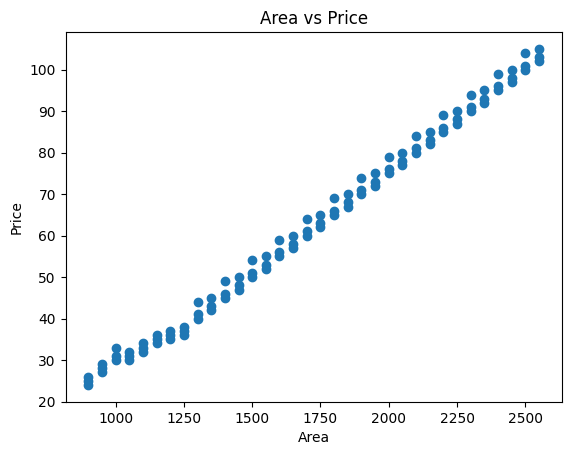

In [29]:
plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [30]:
X = df[["area", "bedrooms", "bathrooms"]]
y = df["price"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = model.predict(X_test)

In [34]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.7346400287774695
R2 Score: 0.9942779382174936


In [35]:
import pandas as pd


def predict_house_price(model):
    print("\nEnter House Details:")

    try:
        area = float(input("Enter area (sq ft): "))
        bedrooms = int(input("Enter number of bedrooms: "))
        bathrooms = int(input("Enter number of bathrooms: "))

        # Validation
        if area <= 0 or bedrooms <= 0 or bathrooms <= 0:
            print("❌ Values must be positive!")
            return

        # Create DataFrame
        new_house = pd.DataFrame(
            [[area, bedrooms, bathrooms]], columns=["area", "bedrooms", "bathrooms"]
        )

        # Prediction
        price = model.predict(new_house)[0]

        print(f"\n💰 Predicted House Price: {round(price,2)} Lakhs")

    except ValueError:
        print("❌ Please enter valid numeric values!")

In [36]:
predict_house_price(model)


Enter House Details:

💰 Predicted House Price: 100.77 Lakhs


In [37]:
y_pred = model.predict(X_test)

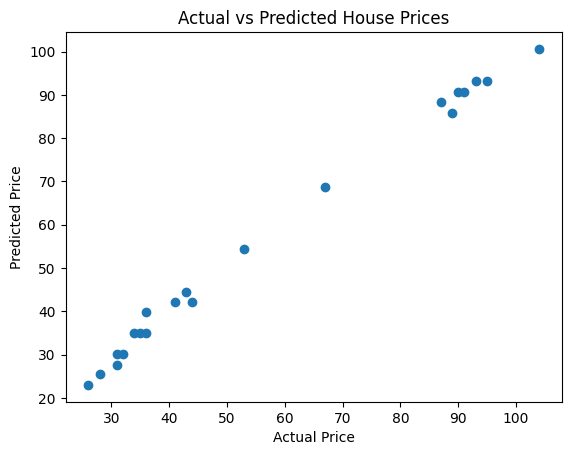

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()


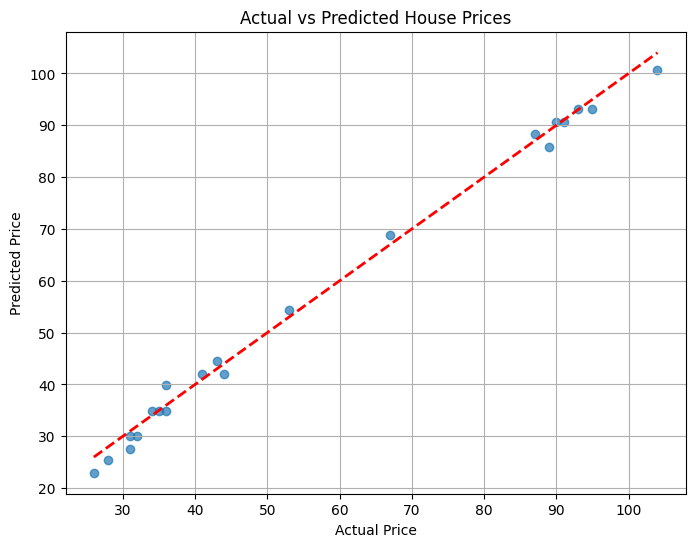

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)

plt.show()

In [ ]:
import os
import joblib


os.makedirs("model", exist_ok=True)

# Save model
joblib.dump(model, "model/house_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
